- 실습 기본 환경 설정


In [1]:

# 예제 실행 및 시각화를 위한 공통 라이브러리 로딩

# 코랩 환경 등 깃허브 전체를 clone해서 실습하는 경우가 아니라면 
# 공통 라이브러리를 불러오기 위해서 별도의 과정이 필요하므로 code_reference/README.md 파일을 확인하자.
import sys
sys.path.append('../../')

from code_reference import common
from code_reference import visualize as viz

# 시각화 결과를 파일에 저장하지 않음
viz.configure(save_grayscale=False)

# matplotlib 시각화에서 한글 폰트 사용 설정
common.set_korean_plot_env()

# 재현성 보장을 위한 시드 고정
#   여기서 재현성은 '동일 컴퓨터, 동일 버전의 파이썬, 동일 버전의 파이토치' 환경에서 재현이 가능하다는 의미로, 
#   독자의 결과는 저자의 결과와 달라질 수 있다는 점을 밝혀둔다.
#   또한 같은 환경에서도 GPU를 사용하는 경우, 일부 연산의 비결정적 성질로 인해 실행시마다 결과가 조금씩 달라질 수 있다.
SEED = 42
common.set_seed(SEED)

# 실습 환경에 맞는 하드웨어 가속기 장치 객체
device = common.get_device()

CUDA를 사용합니다.


# 10-2 (재설계) 인코더만 사용하는 트랜스포머 - 노이즈 속 날짜 형식 분류

본 노트북은 10-2절의 과제를 다음과 같이 다시 정의한 검토용 예제다.

> 앞뒤에 잡음이 섞인 **최대 40자** 문자열을 입력받아, 그 안의 날짜가
> **여섯 가지 형식 중 어느 것인지** 분류한다.

인코더만 사용하는 트랜스포머와 `[CLS]` 토큰 풀링이라는 절의 주제는 그대로
두고, 데이터가 과제의 발목을 잡지 않으면서도 모델이 실제로 일을 하도록
문제를 바꿨다.

## 왜 이렇게 바꿨나

**정상/비정상 이진 분류를 버린 이유.** 정상 형식에 `%d-%m-%Y`(일-월-연)와
`%m/%d/%Y`(월-일-연)가 함께 있어, 일자가 12 이하인 **39.4%**의 날짜에서
순서 오류는 정상 문자열과 표면이 완전히 같아진다. 게다가 "비정상"은 열린
집합이라 유형별 정확도가 모델 성능이 아니라 *어떤 음성을 뽑았는지*의
함수가 된다. 윤년 판정은 1900~2050 범위에서 `2월 29일` 문자열의 전체
모집단이 **151개**뿐이라 일반화 자체가 불가능하다.

**여덟 형식이 아니라 여섯 형식인 이유.** 5월은 전체 이름과 약어가 모두
`May`다. 그래서 `'May 01, 2024'` 한 문자열이 `%B %d, %Y`와 `%b %d, %Y`
두 형식에 동시에 해당한다. 월 이름을 **전체 이름으로만** 쓰는 여섯 형식을
고르면 이 충돌이 성립 자체를 하지 않는다. 형식의 개수는 임의로 정한 것이
아니라 **판별 가능성에서 도출된 수**다.

**노이즈를 섞는 이유.** 깨끗한 입력만 주면 이 과제는 첫 에포크에 정확도
100%에 도달한다. 모델이 일하는 모습을 볼 수 없다. 9-3절에서 Seq2Seq의
변환을 무너뜨렸던 그 노이즈를 그대로 입력에 섞으면, 모델은 40자 잡음
속에서 날짜 구간을 **찾아내** 그 구간의 형식을 판정해야 한다. `[CLS]`
토큰이 실제로 무슨 일을 하는지도 마지막 절의 어텐션 시각화로 확인한다.

다루는 내용
- 판별기를 먼저 만들고 데이터를 그 아래에 두는 설계
- 노이즈가 섞여도 레이블이 유일하게 결정되는지 검증하고, 아니면 폐기
- 인코더만 사용하는 트랜스포머 `DateFormatClassifier`
- 노이즈 길이별 정확도와 혼동 행렬
- `[CLS]`의 층별 어텐션 시각화

이번 절은 본문의 모델 13의 구현을 포함한다. 모델 13의 제시문은 다음과 같다.

> **모델 13. 날짜 형식 분류기 모델**
>
> 날짜 문자열의 앞뒤에 노이즈가 붙은 최대 40자 문자열을 입력받아, 그 안에 담긴 날짜 문자열이 어떤 형식인지 분류하는 모델을 만든다. 9장과 10-1절에서 사용한 날짜 문자열 형식 중 Oct와 같은 월의 약자를 사용하는 두 가지 형식을 제외한 여섯 개의 형식을 대상으로 한다. 여섯 가지 형식과 노이즈를 섞은 입력의 예는 다음 표와 같다. 표에서 월(영어)을 제외한 나머지는 모두 숫자 형식이며, 월과 일 모두 두 자리로 표기한다.
>
> | 레이블 | 형식 | 입력 예시 | 날짜 문자열만 추출 |
> |---|---|---|---|
> |`0`|`일 월(영어) 연도`|`s9d,Wt)-gY9Tq;03 July 1943n$U?Bau*Y`|`03 July 1943`|
> |`1`|`월(영어) 일, 연도`|`d2sG.AhtykjuIi9May 01, 2049+s:c`|`May 01, 2049`|
> |`2`|`월/일/연도`|`>xFxL.lT$@mGFnoZ[11/12/1996d)X@5/)`|`11/12/1996`|
> |`3`|`연도/월/일`|`}]1953/05/24vIx9I/5qnx{>q0,}#D7`|`1953/05/24`|
> |`4`|`일-월-연도`|`w.vHWT!J9vqW[Mri:b!BRi221-05-1926o`|`21-05-1926`|
> |`5`|`연도-월-일`|`hMio;GEh4jD_11981-02-06LaoCPfx*IP`|`1981-02-06`|
>
> 두 형식을 제외한 이유는 `May`(5월)의 전체 이름과 약어가 같아 둘을 구분할 수 없기 때문이다. 

## 1. 여섯 가지 형식과 형식 판별기

데이터를 만들기 전에 **정답을 판정하는 함수부터** 만든다. 생성기가 정답을
주장하는 것이 아니라, 생성기가 만든 문자열을 판별기가 채점하는 구조다.

판별에 `datetime.strptime()`을 쓰지 않는 이유가 두 가지 있다.

- `strptime('2035-6-10', '%Y-%m-%d')`은 **성공**한다. `%m`이 한 자리 수도
  받아들이므로 0 누락을 잡아내지 못한다. 여기서는 `%m`, `%d`를 `\d{2}`로
  둔 정규 표현식을 쓴다.
- `%B`의 월 이름은 시스템 로케일을 따른다. 월 이름은 상수로 고정한다.

입력에 노이즈가 섞이므로 판별기는 `fullmatch`가 아니라 **부분 문자열
검색**(`finditer`)으로 동작해야 한다.

In [2]:
# 참고 - 데이터 생성을 위한 함수

import re
import random
import string
import unicodedata
from calendar import monthrange
from collections import Counter, namedtuple

# 로케일에 영향받지 않도록 월 이름을 상수로 고정
MONTH_FULL = ['', 'January', 'February', 'March', 'April', 'May', 'June',
              'July', 'August', 'September', 'October', 'November', 'December']
MONTH_ABBR = ['', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# 월 이름을 전체 이름으로만 쓰는 여섯 형식(레이블 0~5 순서 유지)
SRC_FORMATS = [
    '%d %B %Y',     # 01 February 2026
    '%B %d, %Y',    # February 01, 2026
    '%m/%d/%Y',     # 02/01/2026
    '%Y/%m/%d',     # 2026/02/01
    '%d-%m-%Y',     # 01-02-2026
    '%Y-%m-%d',     # 2026-02-01
]

NUM_FORMATS = len(SRC_FORMATS)
YEAR_RANGE = (1900, 2050)
MAX_INPUT_LENGTH = 40       # 노이즈를 포함한 입력 문자열의 최대 길이

# (연, 월, 일)을 fmt 형식에 맞춰 날짜 문자열로 변환
def render(year, month, day, fmt):
    text = fmt.replace('%Y', f'{year:04d}').replace('%B', MONTH_FULL[month])
    return text.replace('%m', f'{month:02d}').replace('%d', f'{day:02d}')

# 형식 문자열을 정규 표현식으로 변환하는 함수(%m, %d는 반드시 두 자리)
def _format_to_pattern(fmt):
    parts = []
    for token in re.split(r'(%[YmdB])', fmt):
        if token == '%Y':
            parts.append(r'(?P<year>\d{4})')
        elif token == '%m':
            parts.append(r'(?P<month>\d{2})')
        elif token == '%d':
            parts.append(r'(?P<day>\d{2})')
        elif token == '%B':
            parts.append('(?P<month_full>' + '|'.join(MONTH_FULL[1:]) + ')')
        else:
            parts.append(re.escape(token))
    return re.compile(''.join(parts))


FORMAT_PATTERNS = [(fmt, _format_to_pattern(fmt)) for fmt in SRC_FORMATS]

# 실제 존재하는 날짜인지 확인하는 함수
def is_real_date(year, month, day):
    if not YEAR_RANGE[0] <= year <= YEAR_RANGE[1]:
        return False
    if not 1 <= month <= 12:
        return False
    return 1 <= day <= monthrange(year, month)[1]

# 입력 문자열에서 발견되는 날짜 문자열 형식을 검색해 유일 형식인지를 판단하는 함수
def formats_in(text):
    found = set()
    for index, (fmt, pattern) in enumerate(FORMAT_PATTERNS):
        for matched in pattern.finditer(text):
            group = matched.groupdict()
            month = (MONTH_FULL.index(group['month_full'])
                     if group.get('month_full') else int(group['month']))
            if is_real_date(int(group['year']), month, int(group['day'])):
                found.add(index)
                break
    return found

## 3. 여섯 형식이 서로 구별되는지 전수 검사

"한 문자열이 두 형식에 동시에 해당하는 일"이 없어야 과제가 성립한다.
월과 일의 모든 조합을 빠짐없이 만들어(윤년 2024년과 평년 2025년의 모든
날짜) 확인한다. 어느 하나라도 걸리면 그 아래 데이터는 전부 믿을 수 없다.

In [3]:
# 참고 - 출력 폭을 맞추기 위한 도우미 함수

# 한글처럼 두 칸을 차지하는 글자를 감안해 출력 폭을 맞출 때 사용
def pad(text, width, align='<'):
    display_width = sum(
        2 if unicodedata.east_asian_width(c) in 'WF' else 1 for c in str(text)
    )
    space = ' ' * max(0, width - display_width)
    return space + str(text) if align == '>' else str(text) + space


In [4]:
# 참고 - 생성한 데이터의 형식이 유일하게 구분되는지 확인
# 1. 노이즈가 없는 상태에서의 검사
from datetime import date, timedelta

# 2024년(윤년)과 2025년(평년)의 모든 날짜 = 월/일의 모든 조합
check_dates = []
for year in (2024, 2025):
    day = date(year, 1, 1)
    while day.year == year:
        check_dates.append(day)
        day += timedelta(days=1)

ambiguous = []
for day in check_dates:
    for index, fmt in enumerate(SRC_FORMATS):
        text = render(day.year, day.month, day.day, fmt)
        if formats_in(text) != {index}:
            ambiguous.append((text, fmt, formats_in(text)))

print(f'검사한 문자열 {len(check_dates) * NUM_FORMATS}개 '
      f'(날짜 {len(check_dates)}개 x 형식 {NUM_FORMATS}개)')
print(f'두 형식 이상에 해당하는 문자열: {len(ambiguous)}개')
assert not ambiguous, ambiguous[:5]
print('여섯 형식은 표면만으로 완전히 구별된다.\n')

sample_day = date(2026, 2, 1)
print(pad('레이블', 8) + pad('형식', 12) + '예시')
print('-' * 44)
for index, fmt in enumerate(SRC_FORMATS):
    print(pad(index, 8) + pad(fmt, 12)
          + repr(render(sample_day.year, sample_day.month, sample_day.day, fmt)))

검사한 문자열 4386개 (날짜 731개 x 형식 6개)
두 형식 이상에 해당하는 문자열: 0개
여섯 형식은 표면만으로 완전히 구별된다.

레이블  형식        예시
--------------------------------------------
0       %d %B %Y    '01 February 2026'
1       %B %d, %Y   'February 01, 2026'
2       %m/%d/%Y    '02/01/2026'
3       %Y/%m/%d    '2026/02/01'
4       %d-%m-%Y    '01-02-2026'
5       %Y-%m-%d    '2026-02-01'


## 4. 노이즈를 섞어도 레이블이 유일한가

9-3절의 방식으로 날짜 문자열 앞뒤에 무작위 노이즈를 덧붙여 최대 40자로
만든다. 여기서 새로운 위험이 하나 생긴다. **노이즈가 우연히 두 번째 유효
날짜를 만들어내면** 형식이 유일하게 결정되지 않는다.

```
'2026/02/01' + '/1938'  ->  '2026/02/01/1938'
     뒤쪽에 '02/01/1938' 이 생겨 %Y/%m/%d 와 %m/%d/%Y 둘 다에 해당
```

원리적으로 가능한 일이므로, 생성한 입력을 판별기로 다시 확인해 형식이
유일하지 않으면 **버린다.** 아래에서 그 폐기율을 직접 측정한다.

In [5]:
# 참고 - 노이즈 추가 함수
NOISE_CHARS = (
    string.ascii_letters + string.digits + '!@#$%^&*()_+-=[]{}|;:,./<>?'
)
def add_random_noise(text, rng, max_length=MAX_INPUT_LENGTH):
    """날짜 문자열 앞뒤에 무작위 길이의 무작위 노이즈를 덧붙인다.

    9-1, 9-3, 10-1절의 `add_random_noise()`와 같은 방식이며, 전역 난수
    생성기 대신 주입받은 생성기를 쓰는 점만 다르다.
    """
    prefix, suffix = '', ''
    remaining = max_length - len(text)
    if remaining > 0:
        prefix_length = rng.randint(0, remaining)
        remaining -= prefix_length
        prefix = ''.join(rng.choices(NOISE_CHARS, k=prefix_length))
    if remaining > 0:
        suffix_length = rng.randint(0, remaining)
        suffix = ''.join(rng.choices(NOISE_CHARS, k=suffix_length))
    return prefix + text + suffix


In [6]:
# 참고 - 생성한 데이터의 형식이 유일하게 구분되는지 확인
# 2. 무작위 노이즈를 추가한 상태에서의 검사

# 노이즈를 섞었을 때 레이블이 유일하지 않게 되는 비율 측정
probe_rng = random.Random(2026)
PROBE_SIZE = 20000
collision = 0
collision_examples = []
for _ in range(PROBE_SIZE):
    index = probe_rng.randrange(NUM_FORMATS)
    year = probe_rng.randint(*YEAR_RANGE)
    month = probe_rng.randint(1, 12)
    day = probe_rng.randint(1, monthrange(year, month)[1])
    noisy = add_random_noise(
        render(year, month, day, SRC_FORMATS[index]), probe_rng)
    found = formats_in(noisy)
    if found != {index}:
        collision += 1
        if len(collision_examples) < 3:
            collision_examples.append((noisy, SRC_FORMATS[index], found))

print(f'노이즈 입력 {PROBE_SIZE}개 중 형식이 유일하지 않은 것: '
      f'{collision}개 ({collision / PROBE_SIZE * 100:.3f}%)')
for noisy, fmt, found in collision_examples:
    print(f'  {noisy!r}  지정한 형식={fmt}  가능한 형식={[SRC_FORMATS[i] for i in sorted(found)]}')

노이즈 입력 20000개 중 형식이 유일하지 않은 것: 2개 (0.010%)
  'I<tNhm1F^y)#p>73#h&douE{11909-07-1908jzs'  지정한 형식=%Y-%m-%d  가능한 형식=['%d-%m-%Y', '%Y-%m-%d']
  'UctBt}t]@cdQ81908/09/1964fw_42<i3'  지정한 형식=%Y/%m/%d  가능한 형식=['%m/%d/%Y', '%Y/%m/%d']


## 5. 데이터 생성

여섯 형식에 균등하게 배분하고, 생성한 입력마다

1. 판별기로 **형식이 유일한지** 확인하고 아니면 버리며,
2. 전역 `seen` 집합으로 **중복을 제거**하고,
3. 형식별로 따로 잘라 합치는 **층화 분할**로 훈련/검증/테스트를 나눈다.

같은 문자열이 훈련셋과 검증셋에 동시에 들어가는 누수가 구조적으로 없고,
세 분할의 형식 구성이 모두 같다. 노이즈 길이도 함께 기록해 두었다가
뒤에서 난이도별 정확도를 집계하는 데 쓴다.

In [7]:
# 참고 - 데이터셋 생성

# 데이터셋의 각 샘플을 나타내는 namedtuple
Sample = namedtuple('Sample', 'text label clean noise_length')

# 노이즈가 섞인 날짜 형식 분류 데이터셋을 생성
#   발생 가능한 형식 모호성을 피하기 위해 형식이 유일하게 결정되지 않는 경우 폐기
def build_dataset(total=12000, ratios=(0.64, 0.16, 0.20), seed=42):
    rng = random.Random(seed)
    seen = set()
    discarded = Counter()
    strata = []
    per_format = total // NUM_FORMATS
    for index, fmt in enumerate(SRC_FORMATS):
        samples = []
        while len(samples) < per_format:
            year = rng.randint(*YEAR_RANGE)
            month = rng.randint(1, 12)
            day = rng.randint(1, monthrange(year, month)[1])
            clean = render(year, month, day, fmt)
            text = add_random_noise(clean, rng)
            if text in seen:                    # 중복 제거
                discarded['중복'] += 1
                continue
            if formats_in(text) != {index}:     # 형식이 유일하지 않으면 폐기
                discarded['형식 모호'] += 1
                continue
            seen.add(text)
            samples.append(Sample(text, index, clean, len(text) - len(clean)))
        strata.append(samples)

    train, valid, test = [], [], []
    for group in strata:
        rng.shuffle(group)
        n_train = round(len(group) * ratios[0])
        n_valid = round(len(group) * ratios[1])
        train += group[:n_train]
        valid += group[n_train:n_train + n_valid]
        test += group[n_train + n_valid:]
    for split in (train, valid, test):
        rng.shuffle(split)
    return {'train': train, 'valid': valid, 'test': test}, discarded


dataset, discarded = build_dataset(total=12000)

print(pad('형식', 12) + ''.join(f'{name:>8s}' for name in dataset)
      + pad('평균 길이', 12, '>'))
print('-' * 48)
counters = {name: Counter(s.label for s in split) for name, split in dataset.items()}
all_samples = [s for split in dataset.values() for s in split]
for index, fmt in enumerate(SRC_FORMATS):
    lengths = [len(s.text) for s in all_samples if s.label == index]
    print(pad(fmt, 12) + ''.join(f'{counters[name][index]:>8d}' for name in dataset)
          + pad(f'{sum(lengths) / len(lengths):.1f}', 12, '>'))
print('-' * 48)
print(pad('합계', 12) + ''.join(f'{len(split):>8d}' for split in dataset.values()))

print(f'\n생성 중 폐기: {dict(discarded)}')
texts = {name: {s.text for s in split} for name, split in dataset.items()}
print(f"훈련-검증 중복 {len(texts['train'] & texts['valid'])}건, "
      f"훈련-테스트 중복 {len(texts['train'] & texts['test'])}건")
noise_lengths = [s.noise_length for s in all_samples]
print(f'노이즈 길이: 최소 {min(noise_lengths)}, 최대 {max(noise_lengths)}, '
      f'평균 {sum(noise_lengths) / len(noise_lengths):.1f}')
print('\n예시:')
for s in dataset['train'][:5]:
    print(f'  {s.text!r:<44s} -> {SRC_FORMATS[s.label]:<12s} (원본 {s.clean!r})')

형식           train   valid    test   평균 길이
------------------------------------------------
%d %B %Y        1280     320     400        33.2
%B %d, %Y       1280     320     400        34.0
%m/%d/%Y        1280     320     400        32.4
%Y/%m/%d        1280     320     400        32.5
%d-%m-%Y        1280     320     400        32.8
%Y-%m-%d        1280     320     400        32.5
------------------------------------------------
합계            7680    1920    2400

생성 중 폐기: {'형식 모호': 1}
훈련-검증 중복 0건, 훈련-테스트 중복 0건
노이즈 길이: 최소 0, 최대 30, 평균 21.3

예시:
  '7FKhMio;GEh4jD_11981-02-06LaoCPfx*IP'       -> %Y-%m-%d     (원본 '1981-02-06')
  'r%(vIv1XT0LVQ<yT]8|?_February 26, 1904'     -> %B %d, %Y    (원본 'February 26, 1904')
  '}]1953/05/24vIx9I/5qnx{>q0,}#D7'            -> %Y/%m/%d     (원본 '1953/05/24')
  'd2sG.AhtykjuIi9October 01, 2049+s:c'        -> %B %d, %Y    (원본 'October 01, 2049')
  'eA1948-08-21qbsv*'                          -> %Y-%m-%d     (원본 '1948-08-21')


In [8]:
########################################################################################
# 코드 10-8 - 인코더만 사용하는 트랜스포머 모델, DateFormatClassifier 클래스
########################################################################################
import torch.nn as nn

class DateFormatClassifier(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, ff_dim,
                 num_layers, max_length, num_classes, dropout):
        super().__init__()
        # 입력 토큰 임베딩, 위치 인코딩, 드롭아웃 (10-1 절과 동일)
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_encoding = PositionalEncoding(max_length, d_model)
        self.dropout = nn.Dropout(dropout)

        # 트랜스포머(인코더)의 기본 블록
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=num_heads, dim_feedforward=ff_dim, 
            dropout=dropout, batch_first=True
        )
        # 기본 블록을 여러 개 쌓은 트랜스포머(인코더) 블록
        self.encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers,
            # 중첩 텐서(nested tensor) API 사용 비활성화: 활성화 시 API 관련 경고 발생
            enable_nested_tensor=False,
        )
        # 분류기: [CLS] 토큰의 출력 벡터를 받아 여섯 형식 중 하나로 분류
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, source):
        # PAD 마스크 - Transformer 계열 클래스는 PAD 위치가 True 인 마스크 사용
        #   : UNK는 마스크 대상이 아니므로 모르는 글자도 어텐션에 참여
        pad_mask = (source == PAD_IDX)          # 패딩 마스크: <pad> 위치가 True
        # 토큰 임베딩 + 위치 인코딩 -> 드롭아웃
        x = self.dropout(self.pos_encoding(self.embedding(source)))
        # 인코더의 셀프 어텐션을 통과한 토큰별 콘텍스트 벡터
        output = self.encoder(x, src_key_padding_mask=pad_mask)
        # [CLS](0번 위치)의 출력 벡터를 사용해 형식 분류
        cls_output = output[:, 0, :]            # (B, d_model)
        return self.classifier(cls_output)

형식별 평균 길이가 거의 같다는 점에 주목하자. 날짜 문자열 자체의 길이는
형식마다 다르지만(`'01 September 2026'` 17자 vs `'2026/02/01'` 10자)
노이즈가 그 차이를 덮어, **총 길이만으로는 형식을 알 수 없다.** 모델이
길이라는 지름길을 쓸 여지가 없다는 뜻이다.

## 6. 어휘 사전과 데이터셋 (`[CLS]`, `[UNK]` 포함)

글자 단위 어휘 사전을 만들고, 각 입력 앞에 `[CLS]` 토큰을 붙인다.

`[UNK]` 토큰을 따로 두는 것이 중요하다. 모르는 글자를 `[PAD]`로 바꾸면
모델의 패딩 마스크가 그 위치를 **어텐션에서 통째로 제거**해 버리기 때문에,
"모르는 글자"가 "존재하지 않는 글자"가 되어 버린다. 노이즈가 핵심인 이
과제에서는 치명적인 차이다.

어휘 사전은 **훈련 분할만으로** 만든다.

In [9]:
# 참고 - 어휘 사전 
# 	어휘 사전에 없는 토큰은 [UNK] 토큰으로 바꿔 '모르는 글자'로 취급

import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

CLS_TOKEN, PAD_TOKEN, UNK_TOKEN = '[CLS]', '[PAD]', '[UNK]'
CLS_IDX, PAD_IDX, UNK_IDX = 0, 1, 2
special_tokens = {CLS_TOKEN: CLS_IDX, PAD_TOKEN: PAD_IDX, UNK_TOKEN: UNK_IDX}


class Vocab:
    def __init__(self, texts, special):
        tokens = set()
        for text in texts:
            tokens.update(text)
        self.vocab = dict(special)
        for i, token in enumerate(sorted(tokens)):
            self.vocab[token] = i + len(special)
        self.itos = {v: k for k, v in self.vocab.items()}

    def encode(self, text):
        return [self.vocab.get(c, UNK_IDX) for c in text]

    def __len__(self):
        return len(self.vocab)



In [10]:
########################################################################################
# 코드 10-9 - 입력 앞에 [CLS] 토큰을 추가한 데이터셋 정의
########################################################################################

class DateFormatDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.samples = []
        for text, label in zip(texts, labels):
            # 입력 앞에 [CLS] 토큰 추가
            ids = [CLS_IDX] + vocab.encode(text)
            self.samples.append((ids, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        return self.samples[index]

In [11]:
# 참고 - 배치 병합 함수
#   : 입력 문자열 샘플을 패딩해 길이를 맞추고 텐서로 변환하는 배치 병합 함수를 사용해 데이터로더를 생성

def collate_fn(batch):
    seq_batch, label_batch = zip(*batch)
    seq_tensors = [torch.LongTensor(s) for s in seq_batch]
    src_padded = pad_sequence(seq_tensors, batch_first=True, padding_value=PAD_IDX)
    return src_padded, torch.LongTensor(label_batch)



In [12]:

# 어휘 사전은 훈련 분할만으로 구축한다
vocab = Vocab([s.text for s in dataset['train']], special_tokens)

BATCH_SIZE = 32
loaders = {}
for name, split in dataset.items():
    loaders[name] = DataLoader(
        DateFormatDataset([s.text for s in split], [s.label for s in split], vocab),
        batch_size=BATCH_SIZE, shuffle=(name == 'train'), collate_fn=collate_fn,
    )

letters = ''.join(sorted(t for t in vocab.vocab if len(t) == 1))
print(f'어휘 사전 크기: {len(vocab)} ([CLS] + [PAD] + [UNK] + 글자들)')
print(f'어휘 사전의 글자: {letters!r}')
unseen = ({c for s in dataset['valid'] + dataset['test'] for c in s.text}
          - set(vocab.vocab))
print(f'훈련셋에 없는 글자: {len(unseen)}개 {sorted(unseen)}')

어휘 사전 크기: 93 ([CLS] + [PAD] + [UNK] + 글자들)
어휘 사전의 글자: ' !#$%&()*+,-./0123456789:;<=>?@ABCDEFGHIJKLMNOPQRSTUVWXYZ[]^_abcdefghijklmnopqrstuvwxyz{|}'
훈련셋에 없는 글자: 0개 []


## 7. 학습 가능한 위치 인코딩 (10-1절 [코드 10-1]과 동일)

In [13]:
# 7. 학습 가능한 위치 인코딩
import torch.nn as nn


class PositionalEncoding(nn.Module):
    def __init__(self, max_length, d_model):
        super().__init__()
        self.position_embedding = nn.Embedding(max_length, d_model)
        self.activation = nn.Tanh()

    def forward(self, token_embedded):
        seq_length = token_embedded.size(1)
        positions = torch.arange(seq_length, device=token_embedded.device)
        pos_embedded = self.position_embedding(positions)
        return self.activation(token_embedded + pos_embedded)

## 8. 인코더만 사용하는 트랜스포머 `DateFormatClassifier`

`nn.TransformerEncoderLayer`로 기본 블록을 만들고 `nn.TransformerEncoder`에
주입해 인코더 블록 계층을 만든다. `forward()`는 `[CLS]`(0번 위치)의 출력
벡터만 골라 분류기에 통과시켜 여섯 형식 중 하나로 판정한다.

`[CLS]`는 입력의 어느 글자도 아닌 자리이므로, 문장 전체를 훑어 필요한
정보를 끌어모으는 일 말고는 할 일이 없다. 이 과제에서 그 일이란 **잡음
속에서 날짜 구간을 찾아내는 것**이다. 마지막 절에서 실제로 그렇게
동작하는지 어텐션으로 확인한다.

In [14]:
###############################################################################
# 코드 10-8 - 인코더만 사용하는 트랜스포머 모델, DateFormatClassifier 클래스
###############################################################################
class DateFormatClassifier(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, ff_dim,
                 num_layers, max_length, num_classes, dropout):
        super().__init__()
        # 입력 토큰 임베딩, 위치 인코딩, 드롭아웃 (10-1 절과 동일)
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_encoding = PositionalEncoding(max_length, d_model)
        self.dropout = nn.Dropout(dropout)

        # 트랜스포머(인코더)의 기본 블록
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=num_heads,
            dim_feedforward=ff_dim, dropout=dropout,
            batch_first=True,
        )
        # 기본 블록을 여러 개 쌓은 트랜스포머(인코더) 블록
        self.encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers,
            # 중첩 텐서(nested tensor) API 사용 비활성화 - 실험적 API 경고 방지
            enable_nested_tensor=False,
        )
        # 분류기 - [CLS] 토큰의 출력 벡터를 받아 여섯 형식 중 하나로 분류
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, source):
        # PAD 마스크 - Transformer 계열 클래스는 PAD 위치가 True 인 마스크 사용
        # UNK 는 마스크 대상이 아니므로 모르는 글자도 어텐션에 참여한다
        pad_mask = (source == PAD_IDX)
        x = self.dropout(self.pos_encoding(self.embedding(source)))
        output = self.encoder(x, src_key_padding_mask=pad_mask)
        # [CLS](0번 위치)의 출력 벡터를 사용해 형식 분류
        cls_output = output[:, 0, :]            # (B, d_model)
        return self.classifier(cls_output)

## 9. 학습 함수와 학습

정답이 순차 데이터가 아닌 분류 레이블이므로, 모델에는 입력만 전달하고
정답은 손실 계산에만 사용한다.

In [15]:
# 참고 - 학습 함수

import copy

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    loss_sum, sample_size, correct_size = 0.0, 0, 0
    for src, labels in loader:
        src, labels = src.to(device), labels.to(device)
        optimizer.zero_grad()
        # 모델에는 입력 문자열만 전달(정답 레이블은 전달하지 않음)
        logits = model(src)                         # (B, NUM_FORMATS)
        # 정답은 손실을 계산하는 용도로만 사용, ignore_index 인자 사용하지 않음
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        batch_size = src.size(0)
        loss_sum += loss.item() * batch_size
        sample_size += batch_size
        correct_size += (logits.argmax(1) == labels).sum().item()
    return loss_sum / sample_size, correct_size / sample_size * 100.0


@torch.no_grad()
def validation(model, loader, criterion, device):
    model.eval()
    loss_sum, sample_size, correct_size = 0.0, 0, 0
    for src, labels in loader:
        src, labels = src.to(device), labels.to(device)
        logits = model(src)
        loss = criterion(logits, labels)
        batch_size = src.size(0)
        loss_sum += loss.item() * batch_size
        sample_size += batch_size
        correct_size += (logits.argmax(1) == labels).sum().item()
    return loss_sum / sample_size, correct_size / sample_size * 100.0


def train_loop(model, train_loader, valid_loader, criterion, optimizer,
               epochs, patience, device):
    model.to(device)
    log = common.EpochLogger(epochs)
    best_valid_loss = float('inf')
    best_state, counter = None, 0
    stopped = False
    for epoch in range(1, epochs + 1):
        train_loss, _ = train_epoch(
            model, train_loader, criterion, optimizer, device)
        valid_loss, valid_acc = validation(
            model, valid_loader, criterion, device)
        log.row(epoch, train_loss, valid_loss, valid_acc)
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_state = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                stopped = True
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    log.summary(stopped='조기 종료' if stopped else None)
    return log

In [16]:
# 참고 - 모델 객체 생성과 학습
import torch.optim as optim

# 모델 구조 하이퍼파라미터
D_MODEL = 64
NUM_HEADS = 4
FF_DIM = 128
NUM_LAYERS = 2
MAX_LENGTH = 48             # 입력 최대 40자 + [CLS] + 여유
DROPOUT = 0.1

# 학습 설정 하이퍼파라미터
LR = 1e-3
EPOCHS = 60
PATIENCE = 8

# 결과 재현을 위한 시드값 고정
common.set_seed(SEED)

# 모델 객체 생성
model = DateFormatClassifier(
    vocab_size=len(vocab), d_model=D_MODEL, num_heads=NUM_HEADS,
    ff_dim=FF_DIM, num_layers=NUM_LAYERS, max_length=MAX_LENGTH,
    num_classes=NUM_FORMATS, dropout=DROPOUT
).to(device)

# 손실 함수와 옵티아미저 생성
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# 모델 학습 실행
log = train_loop(model, loaders['train'], loaders['valid'],
                 criterion, optimizer, EPOCHS, PATIENCE, device)

에포크    훈련 손실    검증 손실    정확도(%)     시간
  1/60       0.8377       0.6126       62.71%     0:03
  6/60       0.5416       0.5469       65.78%     0:15
 12/60       0.4710       0.5040       69.53%     0:29
 18/60       0.3762       0.3984       81.61%     0:43
 24/60       0.2410       0.2345       90.78%     0:57
 30/60       0.1414       0.1259       95.52%     1:10
 36/60       0.1032       0.1018       97.03%     1:26
 42/60       0.0736       0.0903       97.97%     1:41
 48/60       0.0648       0.0879       97.60%     1:55
 54/60       0.0497       0.0687       98.28%     2:09
------------------------------------------------------
최적 46 에포크 · 검증 손실 0.0673 · 전체 학습 시간 2:09 · (조기 종료)


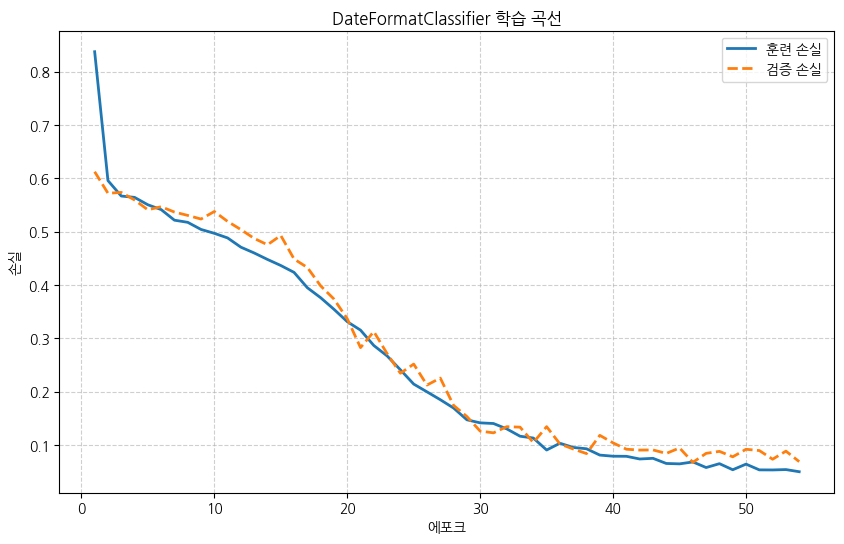

In [17]:
# 참고 - 학습 곡선 시각화
log.plot(title='DateFormatClassifier 학습 곡선')

## 10. 평가 - 형식별 정확도와 혼동 행렬

정답이 여섯 개로 닫혀 있으므로 혼동 행렬을 그릴 수 있다. 기존 이진 분류
과제에서는 "비정상"이 열린 집합이라 이런 분석이 불가능했다.

테스트셋 정확도: 97.96% (2351/2400)

형식           샘플 수   정확도(%)
----------------------------------
%d %B %Y           400        97.8
%B %d, %Y          400       100.0
%m/%d/%Y           400        96.0
%Y/%m/%d           400        98.2
%d-%m-%Y           400        96.0
%Y-%m-%d           400        99.8


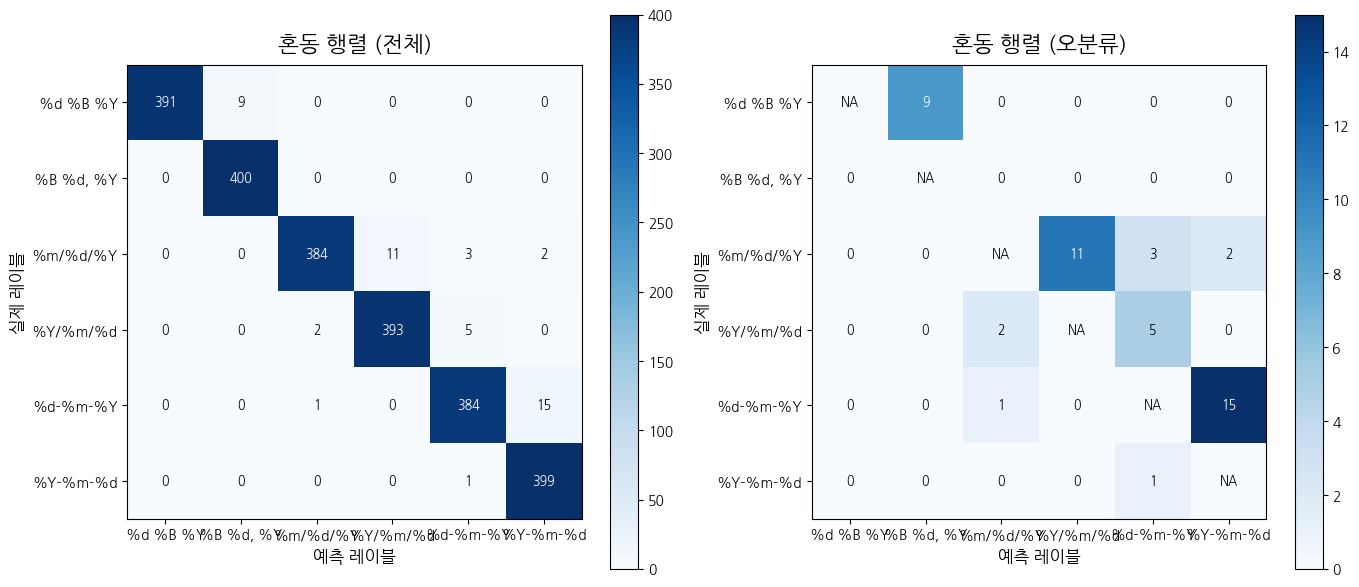

In [18]:
# 참고 - 정확도 계산 및 혼동 행렬 시각화
accuracy, n_correct, n_samples = common.get_accuracy(model, loaders['test'], device)
print(f'테스트셋 정확도: {accuracy:.2f}% ({n_correct}/{n_samples})')

confusion_matrix = common.get_confusion_matrix(
    model, loaders['test'], num_classes=NUM_FORMATS, device=device)

print(f'\n{pad("형식", 12)}{pad("샘플 수", 10, ">")}{pad("정확도(%)", 12, ">")}')
print('-' * 34)
for index, fmt in enumerate(SRC_FORMATS):
    row = confusion_matrix[index]
    total = row.sum().item()
    print(pad(fmt, 12) + pad(total, 10, '>')
          + pad(f'{row[index].item() / total * 100:.1f}', 12, '>'))

viz.plot_confusion_matrix(confusion_matrix, class_names=SRC_FORMATS)

## 11. 오분류 사례 뜯어보기

혼동 행렬은 어떤 형식을 어떤 형식으로 착각하는지 보여 주지만, 각 칸에 몇 건이
모여 있는지만 알려 줄 뿐 그 안을 보여 주지는 않는다. 오분류를 (정답 형식 ->
예측 형식) 쌍으로 묶어 하나도 빠짐없이 출력하면, 모델이 어떤 입력에서 무너지는지
직접 확인할 수 있다.

In [19]:
# 참고 - 오분류 사례 전체 출력(오류 유형별)

# 각 분할된 데이터셋 전체에 대한 예측 레이블과 신뢰도를 한 번에 계산
@torch.no_grad()
def predict_split(model, samples, vocab, device, batch_size=128):
    model.eval()
    preds, confidences = [], []
    for start in range(0, len(samples), batch_size):
        chunk = samples[start:start + batch_size]
        seq_tensors = [
            torch.LongTensor([CLS_IDX] + vocab.encode(s.text)) for s in chunk
        ]
        src = pad_sequence(
            seq_tensors, batch_first=True, padding_value=PAD_IDX).to(device)
        probs = torch.softmax(model(src), dim=1)
        confidence, pred = probs.max(dim=1)
        preds += pred.tolist()
        confidences += confidence.tolist()
    return preds, confidences

test_samples = dataset['test']
test_preds, test_confidences = predict_split(model, test_samples, vocab, device)

# 오분류를 (정답 형식, 예측 형식) 쌍으로 취합
errors = {}
for sample, pred, confidence in zip(test_samples, test_preds, test_confidences):
    if pred != sample.label:
        errors.setdefault((sample.label, pred), []).append((sample, confidence))

error_size = sum(len(cases) for cases in errors.values())
print(f'테스트셋 {len(test_samples)}개 중 오분류 {error_size}건, '
      f'(정답 -> 예측) 유형 {len(errors)}가지')

# 건수가 많은 유형부터, 유형 안에서는 신뢰도가 높은(더 확신하며 틀린) 순서로 출력
for (label, pred), cases in sorted(errors.items(), key=lambda kv: -len(kv[1])):
    print(f'[정답 {SRC_FORMATS[label]} -> 예측 {SRC_FORMATS[pred]}] {len(cases)}건')
    for sample, confidence in sorted(cases, key=lambda case: -case[1]):
        print(f'  {sample.text!r:<44s} 포함된 날짜 문자열 {sample.clean!r:<21s} '
              f'노이즈 {sample.noise_length:>2d}자  신뢰도 {confidence * 100:5.1f}%')
    print()

테스트셋 2400개 중 오분류 49건, (정답 -> 예측) 유형 9가지
[정답 %d-%m-%Y -> 예측 %Y-%m-%d] 15건
  'JXBC#a<A<_d{-2]+2YG*907-04-1969Rd['         포함된 날짜 문자열 '07-04-1969'          노이즈 24자  신뢰도  99.9%
  'bn[PakHG+}h4o^aNx4Fj926-03-1967<,'          포함된 날짜 문자열 '26-03-1967'          노이즈 23자  신뢰도  99.5%
  ',IXYV{|HKmS[<w>025-08-1923t6=J4}8,%z6#mq'   포함된 날짜 문자열 '25-08-1923'          노이즈 30자  신뢰도  99.2%
  ')4Fg{!gxi907-12-2035$|>PeCLfxQwk8@3%|iU&'   포함된 날짜 문자열 '07-12-2035'          노이즈 30자  신뢰도  99.0%
  'n6V1N/{MkyXam$Aa24-12-2017^xv0%f-N[ay;V'    포함된 날짜 문자열 '24-12-2017'          노이즈 29자  신뢰도  97.5%
  'g/^OAa-16921-02-2036c#+Bb@sk/'              포함된 날짜 문자열 '21-02-2036'          노이즈 19자  신뢰도  96.7%
  '-{cT]m&Az50yCMsm-p>Xw27-07-2038+1'          포함된 날짜 문자열 '27-07-2038'          노이즈 23자  신뢰도  94.3%
  '6+>l+SMy-10-02-1952-LF;!e*7ng;!Eb)j'        포함된 날짜 문자열 '10-02-1952'          노이즈 25자  신뢰도  93.0%
  'px_Gq2R+:*>XM+<.2s9w7<27-01-2050DA'         포함된 날짜 문자열 '27-01-2050'          노이즈 24자  신뢰도  88.8%
  'ev|)0VQ<g#Uc(o4Veh9,u[14

## 12. 노이즈 길이별 정확도와 신뢰도

이 과제의 난이도는 노이즈 길이가 결정한다. 테스트셋을 노이즈 길이 구간으로
나누어 정확도와 평균 신뢰도를 함께 본다. 신뢰도는 소프트맥스 확률 중
예측한 클래스의 값이다.

In [20]:
# 참고 - 노이즈 길이 구간 별 정확도와 평균 신뢰도 계산

BUCKETS = [(0, 5), (6, 10), (11, 15), (16, 20), (21, 25), (26, 30)]
print(pad('노이즈 길이', 14) + pad('샘플 수', 10, '>')
      + pad('정확도(%)', 12, '>') + pad('평균 신뢰도(%)', 16, '>'))
print('-' * 52)
for low, high in BUCKETS:
    picked = [
        (s, p, c) for s, p, c in zip(test_samples, test_preds, test_confidences)
        if low <= s.noise_length <= high
    ]
    if not picked:
        continue
    correct = sum(p == s.label for s, p, _ in picked)
    confidence_sum = sum(c for _, _, c in picked)
    label = f'{low}' if low == high else f'{low}~{high}'
    print(pad(label, 14) + pad(len(picked), 10, '>')
          + pad(f'{correct / len(picked) * 100:.1f}', 12, '>')
          + pad(f'{confidence_sum / len(picked) * 100:.1f}', 16, '>'))

노이즈 길이      샘플 수   정확도(%)  평균 신뢰도(%)
----------------------------------------------------
0~5                   48       100.0            99.4
6~10                 175        99.4            99.3
11~15                268        99.6            99.4
16~20                409        98.0            99.2
21~25                709        97.3            99.1
26~30                791        97.5            98.4


## 13. 신뢰도를 함께 출력하는 예측 함수

In [21]:
########################################################################################
# 코드 10-10 - 분류 결과의 신뢰도를 계산하는 예측 함수
########################################################################################
@torch.no_grad()
def predict(model, input_text, vocab, device):
    model.eval()
    # 입력 앞에 [CLS] 토큰을 추가한 후, 배치 차원을 추가한 텐서를 예측에 사용
    ids = [CLS_IDX] + vocab.encode(input_text)
    src = torch.LongTensor(ids).unsqueeze(0).to(device)
    logits = model(src)
    # 소프트맥스 확률로 변환한 후, 예측 클래스와 그 확률(예측 신뢰도) 계산
    probs = torch.softmax(logits, dim=1)
    pred = logits.argmax(1).item()
    return pred, probs[0][pred].item()

# 같은 날짜를 여섯 형식으로 만들고, 같은 노이즈를 추가해 확인
demo_rng = random.Random(10)
test_day = date(1938, 10, 31)
print(pad('입력', 46) + pad('정답 형식', 13) + pad('예측 형식', 13)
      + pad('신뢰도', 7, '>') + '  정답 여부')
print('-' * 90)
for index, fmt in enumerate(SRC_FORMATS):
    clean = render(test_day.year, test_day.month, test_day.day, fmt)
    text = add_random_noise(clean, demo_rng)
    pred, confidence = predict(model, text, vocab, device)
    print(pad(repr(text), 46) + pad(fmt, 13) + pad(SRC_FORMATS[pred], 13)
          + pad(f'{confidence * 100:.1f}%', 7, '>') + ' ' * 10
          + ('O' if pred == index else 'X'))

입력                                          정답 형식    예측 형식     신뢰도  정답 여부
------------------------------------------------------------------------------------------
'cQbPRy_dRg.%GLmFL+31 October 1938O96l'       %d %B %Y     %d %B %Y      100.0%          O
'[vNHZur|V&v7OP6CS-<vcA1gOctober 31, 1938'    %B %d, %Y    %B %d, %Y     100.0%          O
'[nYH1k*io).MKvy2pkOo5+*QEMa@D10/31/1938v'    %m/%d/%Y     %m/%d/%Y      100.0%          O
'NZI]7vU;1938/10/31QSo8}mWFI!Xi<+]N'          %Y/%m/%d     %Y/%m/%d       99.9%          O
'ei31-10-19382-)'                             %d-%m-%Y     %d-%m-%Y       99.7%          O
'OMSN1938-10-31x(ODUU$Ccr|Z3ckA=vzh1X>'       %Y-%m-%d     %Y-%m-%d       99.5%          O


## 14. `[CLS]`는 어디를 보고 있나

`[CLS]`는 입력의 어느 글자도 아니므로, 분류에 필요한 정보를 셀프 어텐션으로
직접 끌어와야 한다. 이 과제에서 그 정보는 **잡음 속 날짜 구간**에 있다.

`nn.TransformerEncoderLayer`는 어텐션 가중치를 내보내지 않으므로, 각 층의
입력을 그대로 그 층의 `self_attn`에 `need_weights=True`로 한 번 더 통과시켜
가중치를 얻는다. 아래 히트맵의 각 행은 한 층에서 `[CLS]`가 입력의 각
글자에 준 어텐션이다.

입력      : 'o!z/941AduDvLw;TDEK}1uO^{;w11/04/2043'
날짜 구간 : '11/04/2043' (노이즈 27자)
예측      : %m/%d/%Y (신뢰도 99.0%)

층        날짜 구간 어텐션 비중(%)
----------------------------------
1층                           55.0
2층                           73.6

(날짜 구간은 전체 38자 중 10자, 26.3%를 차지)


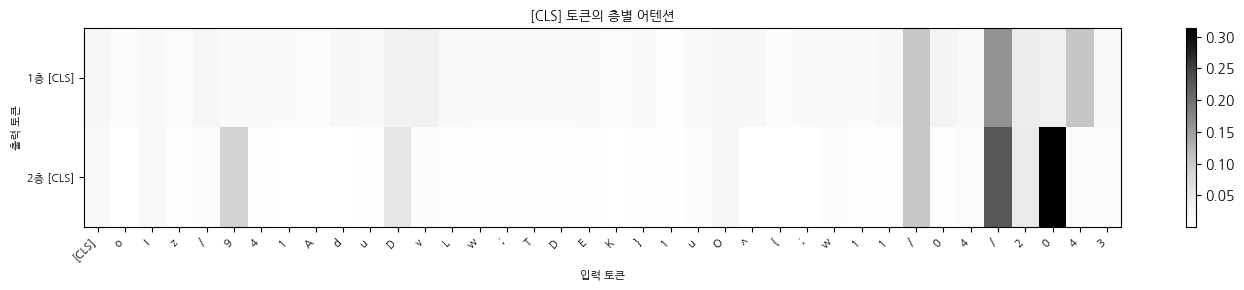

In [22]:
# 참고 - [CLS]의 셀프 어텐션 추출(트랜스포머 블록 층별)

# 각 인코더 블록에서 [CLS] 토큰의 입력 토큰별 어텐션 수집
@torch.no_grad()
def get_cls_attention(model, input_text, vocab, device):
    model.eval()
    ids = [CLS_IDX] + vocab.encode(input_text)
    src = torch.LongTensor(ids).unsqueeze(0).to(device)
    pad_mask = (src == PAD_IDX)
    # 모델의 forward와 같은 순서로 입력을 생성(eval 모드이므로 드롭아웃은 항등 함수)
    x = model.dropout(model.pos_encoding(model.embedding(src)))

    rows = []
    for layer in model.encoder.layers:
        # 층이 실제로 수행하는 것과 같은 셀프 어텐션을 가중치와 함께 다시 계산
        _, weights = layer.self_attn(
            x, x, x, key_padding_mask=pad_mask,
            need_weights=True, average_attn_weights=True
        )
        rows.append(weights[0, 0])                   # [CLS] 행(헤드 평균)
        x = layer(x, src_key_padding_mask=pad_mask)  # 다음 층의 입력
    tokens = [CLS_TOKEN] + list(input_text)
    return torch.stack(rows).cpu(), tokens


# 노이즈가 충분히 긴, 맞게 분류한 테스트 샘플을 하나 선택
target = next(
    s for s, p in zip(test_samples, test_preds)
    if p == s.label and s.noise_length >= 20
)
attention, tokens = get_cls_attention(model, target.text, vocab, device)
pred, confidence = predict(model, target.text, vocab, device)

print(f'입력      : {target.text!r}')
print(f'날짜 구간 : {target.clean!r} (노이즈 {target.noise_length}자)')
print(f'예측      : {SRC_FORMATS[pred]} (신뢰도 {confidence * 100:.1f}%)')

# 날짜 문자열 구간에 배분된 어텐션의 비율을 층별로 계산
start = target.text.index(target.clean) + 1      # +1 은 맨 앞의 [CLS] 토큰
end = start + len(target.clean)
print(f'\n{pad("층", 8)}{pad("날짜 구간 어텐션 비중(%)", 26, ">")}')
print('-' * 34)
for layer_index, row in enumerate(attention, start=1):
    share = row[start:end].sum().item() / row.sum().item() * 100
    print(pad(f'{layer_index}층', 8) + pad(f'{share:.1f}', 26, '>'))
print(f'\n(날짜 구간은 전체 {len(tokens)}자 중 {len(target.clean)}자, '
      f'{len(target.clean) / len(tokens) * 100:.1f}%를 차지)')

viz.plot_attention(
    attention,
    source_tokens=tokens,
    target_tokens=[f'{i}층 [CLS]' for i in range(1, len(attention) + 1)],
    title='[CLS] 토큰의 층별 어텐션', figsize=(14, 3), font_scale=0.8,
)

## 정리

- **판별기를 먼저 만들고 전수 검사를 돌린 덕분에 설계 결함을 미리 잡았다.**
  5월은 전체 이름과 약어가 모두 `May`라서 약어 형식을 포함하면 데이터가
  성립하지 않는다. 여섯이라는 형식 수는 임의로 정한 것이 아니라 판별
  가능성에서 도출된 값이다.
- **노이즈는 레이블을 망가뜨릴 수 있다.** 잡음이 우연히 두 번째 유효 날짜를
  만들면 형식이 유일하지 않게 된다. 실제 노이즈 문자 집합에서는 거의
  일어나지 않지만, 생성 단계에서 판별기로 확인해 걸러 두면 비용 없이
  안전하다.
- **정답이 닫힌 집합**이라 혼동 행렬과 형식별 정확도가 모델의 성질을 그대로
  반영한다. 개방집합 음성에 기대던 기존 과제와 가장 크게 달라지는 점이다.
- `[UNK]`를 `[PAD]`와 분리해야 모르는 글자가 어텐션에서 사라지지 않는다.
  노이즈가 핵심 단서인 이 과제에서는 특히 중요하다.
- `[CLS]`가 잡음이 아니라 **날짜 구간에 어텐션을 모으는 것**을 층별 히트맵으로
  확인할 수 있다. 인코더 온리 구조에서 `[CLS]` 풀링이 왜 동작하는지를
  말이 아니라 그림으로 보여 주는 자리다.

### 연습 문제로 돌릴 만한 것

1. 노이즈 길이를 40자보다 더 늘리면 정확도는 어디까지 떨어지는가?
   위치 인코딩의 `max_length`도 함께 늘려야 한다는 점에 주의하자.
2. `[UNK]`를 쓰지 않고 모르는 글자를 `[PAD]`로 바꾸도록 `Vocab.encode()`를
   되돌리면 정확도가 어떻게 달라지는가? 왜 그런지 패딩 마스크와 함께 설명하라.
3. 날짜 존재 여부(윤년, 월별 일수) 판정을 이 모델에 추가로 학습시켜 보고,
   왜 윤년 판정만 유독 학습되지 않는지 설명하라. 1900~2050 범위에서
   `2월 29일` 형태 문자열의 전체 모집단이 몇 개인지 세어 보면 실마리가 된다.
4. 헤드 수를 1로 줄이면 `[CLS]`의 어텐션 그림이 어떻게 달라지는가?